# Análise dos Cancelamentos do Teste do Pezinho

Este notebook tem como objetivo analisar os dados de cancelamentos de amostras do Teste do Pezinho, identificando padrões, principais motivos, unidades e municípios com maiores índices, além de avaliar a atuação dos profissionais envolvidos.

## Sumário

1. [Configuração do ambiente](#configuração-de-ambiente)
2. [Leitura e exploração dos dados](#analisando-as-tabelas)
3. [Relacionamento entre os datasets](#analisando-os-dados-e-relacionando-os-dataset)
4. [Análise dos cancelamentos](#análise-específica-dos-cancelamentos-e-seus-motivos)
5. [Ranking por unidade e município](#top-15-unidades-de-saúde-com-mais-cancelamentos)
6. [Análise por profissão](#ranking-final-taxa-de-cancelamento-por-profissão-top-10)
7. [Conclusões](#conclusões)

---

> **Observação:** As etapas seguintes incluem tratamento de dados, visualizações e análises estatísticas para apoiar a tomada de decisão e propor melhorias no processo.


## Configuração de ambiente

In [4]:
# importando as libs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# carregando os arquivos 
df_amostra = pd.read_csv('./datasets1/tb_amostra.csv')
df_motivo_inadequacao = pd.read_csv('./datasets1/tb_motivo_inadequacao.csv')
df_ms_motivo_inadequacao = pd.read_csv('./datasets1/tb_ms_motivo_inadequacao.csv')
df_municipio = pd.read_csv('./datasets1/tb_municipio.csv')
df_unidade_saude = pd.read_csv('./datasets1/tb_unidade_saude.csv')
df_profissao = pd.read_csv('./datasets1/tb_profissao.csv') 
df_profissional_saude= pd.read_csv('./datasets1/tb_profissional_saude.csv') 

In [6]:
# Verificando informações gerais dos DataFrames

dfs = {
    "df_amostra": df_amostra,
    "df_motivo_inadequacao": df_motivo_inadequacao,
    "df_ms_motivo_inadequacao": df_ms_motivo_inadequacao,
    "df_municipio": df_municipio,
    "df_unidade_saude": df_unidade_saude,
    "df_profissao": df_profissao,
    "df_profissional_saude": df_profissional_saude
}

for nome, df in dfs.items():
    print(f"\n--- {nome} ---")
    display(df.info())
    display(df.describe(include='all', datetime_is_numeric=True))
    print("Valores nulos por coluna:")
    print(df.isna().sum())
    print("Duplicatas:", df.duplicated().sum())


--- df_amostra ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554474 entries, 0 to 554473
Data columns (total 19 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   co_seq_amostra               554474 non-null  int64  
 1   co_seq_tp_amostra            554474 non-null  int64  
 2   co_seq_pessoa                554474 non-null  int64  
 3   co_seq_tp_material_coletado  554474 non-null  int64  
 4   co_seq_unidade_saude         554474 non-null  int64  
 5   nu_amostra                   554474 non-null  int64  
 6   ide_controle_medico          554474 non-null  object 
 7   ide_portador                 554474 non-null  object 
 8   dt_col_amostra               554445 non-null  float64
 9   hr_col_amostra               1405 non-null    float64
 10  dt_post_amostra              169 non-null     float64
 11  dt_rec_amostra               554474 non-null  int64  
 12  dt_hr_cancelamento           596 non-n

None

TypeError: NDFrame.describe() got an unexpected keyword argument 'datetime_is_numeric'

### Analisando as tabelas

#### df_amostra

In [ ]:
# 5 primeiras linhas da df_amostra
df_amostra.head(5)


,co_seq_amostra,co_seq_tp_amostra,co_seq_pessoa,co_seq_tp_material_coletado,co_seq_unidade_saude,nu_amostra,ide_controle_medico,ide_portador,dt_col_amostra,hr_col_amostra,dt_post_amostra,dt_rec_amostra,dt_hr_cancelamento,aut_cancelamento,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,ide_transfusao_amostra
0,80645,1,79939,1,622,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080559,carliane,20190716080559,carliane,N
1,80646,1,79940,1,623,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080714,carliane,20190716080714,carliane,N
2,80596,1,79894,1,237,1,N,N,20190701.0,NaN,NaN,20190715,NaN,NaN,20190715165933,cristiana,20190715165933,cristiana,N
3,80647,1,79941,1,623,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080807,carliane,20190716080807,carliane,N
4,80648,1,79942,1,275,1,N,N,20190709.0,NaN,NaN,20190716,NaN,NaN,20190716080950,carliane,20190716080950,carliane,N


In [ ]:
# 5 ultimas linhas da df_amostra
df_amostra.tail(5)

,co_seq_amostra,co_seq_tp_amostra,co_seq_pessoa,co_seq_tp_material_coletado,co_seq_unidade_saude,nu_amostra,ide_controle_medico,ide_portador,dt_col_amostra,hr_col_amostra,dt_post_amostra,dt_rec_amostra,dt_hr_cancelamento,aut_cancelamento,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,ide_transfusao_amostra
554469,80640,1,79934,1,626,1,N,N,20190703.0,NaN,NaN,20190716,NaN,NaN,20190716080146,carliane,20190716080146,carliane,N
554470,80641,1,79935,1,625,1,N,N,20190703.0,NaN,NaN,20190716,NaN,NaN,20190716080318,carliane,20190716080318,carliane,N
554471,80642,1,79936,1,275,1,N,N,20190713.0,NaN,NaN,20190716,NaN,NaN,20190716080324,hiago,20190716080324,hiago,N
554472,80643,1,79937,1,632,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080417,carliane,20190716080417,carliane,N
554473,80644,1,79938,1,275,1,N,N,20190713.0,NaN,NaN,20190716,NaN,NaN,20190716080455,hiago,20190716080455,hiago,N


#### df_motivo_inadequacao

In [ ]:
# 5 primeiras linhas da df_motivo_inadequacao
df_motivo_inadequacao.head(5)

,co_mot_inadequacao,ds_mot_inadequacao,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,ide_outro
0,0,Não identificado,20130501000000,Implantação,20130501000000,Implantação,N
1,1,Os cinco círculos não foram preenchidos,20130501000000,Implantação,20130501000000,Implantação,N
2,2,A área do(s) círculo(s) não foi (foram) totalm...,20130501000000,Implantação,20130501000000,Implantação,N
3,3,"Gota muito pequena, insuficiente para análise",20130501000000,Implantação,20130501000000,Implantação,N
4,4,"Gota não penetrou totalmente no papel, não ati...",20130501000000,Implantação,20130501000000,Implantação,N


In [ ]:
# 5 ultimas linhas da df_motivo_inadequacao
df_motivo_inadequacao.tail(5)

,co_mot_inadequacao,ds_mot_inadequacao,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,ide_outro
19,19,Volume insuficiente,20151203161101,ADMIN,20151203161101,ADMIN,N
20,20,Tubo vazio,20151203161101,ADMIN,20151203161101,ADMIN,N
21,21,Material danificado,20151203161101,ADMIN,20151203161101,ADMIN,N
22,22,Sangue colocado na frente e no verso não penet...,20160622140101,ADMIN,20160622140101,ADMIN,N
23,23,Erro na identificação do material,20170125160701,ADMIN,20170125160701,ADMIN,N


#### df_ms_motivo_inadequacao 

In [ ]:
# 5 primeiras linhas da df_ms_motivo_inadequacao
df_ms_motivo_inadequacao.head(5)

,co_seq_ms_motivo_inadequacao,co_mot_inadequacao,co_mot_inad
0,1,1,1
1,2,2,2
2,3,3,3
3,4,4,4
4,5,5,5


In [ ]:
# 5 ultimas linhas da df_ms_motivo_inadequacao
df_ms_motivo_inadequacao.tail(5)

,co_seq_ms_motivo_inadequacao,co_mot_inadequacao,co_mot_inad
11,12,12,10
12,13,13,11
13,14,14,12
14,15,15,13
15,16,16,99


#### df_municipio

In [ ]:
# 5 primeiras linhas da df_municipio
df_municipio.head(5)

,co_seq_municipio,co_seq_macroregiao,co_seq_distrito,co_seq_mesoregiao,co_seq_uf,co_seq_regional,co_seq_polo,co_seq_microregiao,co_seq_consorcio,co_ibge,no_municipio,dst_centro_referencia,obs_municipio,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro
0,1,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN,1100015,Alta Floresta D'Oeste,0.0,NaN,20130501000000,Implantação,20130501000000,Implantação
1,2,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN,1100023,Ariquemes,0.0,NaN,20130501000000,Implantação,20130501000000,Implantação
2,3,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN,1100031,Cabixi,0.0,NaN,20130501000000,Implantação,20130501000000,Implantação
3,4,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN,1100049,Cacoal,0.0,NaN,20130501000000,Implantação,20130501000000,Implantação
4,5,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN,1100056,Cerejeiras,0.0,NaN,20130501000000,Implantação,20130501000000,Implantação


In [ ]:
# 5 ultimas linhas da df_municipio
df_municipio.tail(5)

,co_seq_municipio,co_seq_macroregiao,co_seq_distrito,co_seq_mesoregiao,co_seq_uf,co_seq_regional,co_seq_polo,co_seq_microregiao,co_seq_consorcio,co_ibge,no_municipio,dst_centro_referencia,obs_municipio,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro
5560,3095,10.0,NaN,9.0,31,NaN,2.0,2.0,NaN,3172103,Volta Grande,NaN,NaN,20130501000000,Implantação,20130501000000,Implantação
5561,3096,6.0,NaN,2.0,31,NaN,40.0,30.0,NaN,3172202,Wenceslau Braz,85.0,NaN,20170213105803,ana.flavia,20130501000000,Implantação
5562,653,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,2112209,Timon,0.0,NaN,20210118084228,rosilene,20130501000000,Implantação
5563,452,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,2100154,Agua Doce do Maranhão,0.0,NaN,20220422073106,yago,20130501000000,Implantação
5564,564,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,2106607,MATOES,0.0,NaN,20220621073343,yago,20130501000000,Implantação


#### df_unidade_saude

In [ ]:
# 5 primeiras linhas da df_unidade_saude
df_unidade_saude.head(5)

,co_seq_unidade_saude,co_seq_distrito,co_seq_tp_logradouro,co_seq_municipio,no_unidade_saude,co_ref_unidade,nu_cnes,no_logradouro,nu_logradouro,cmp_nr_logradouro,no_bairro,nu_cep,nu_telefone,nu_fax,ds_email,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,nu_telefone_auxiliar
0,1,NaN,113,450,SEC.MUNIC. DE ACAILANDIA,00535-01,6383572,ANITA GARIBALDE ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20170908095401,Implantação,20170908095401,Implantação,NaN
1,2,NaN,113,451,SEMUS AFONSO CUNHA,00679-01,7946724,ANTONIO BACELAR,S/N,NaN,PRACA DA COMUNIDADE,NaN,NaN,NaN,NaN,20170908095401,Implantação,20170908095401,Implantação,NaN
2,8,NaN,113,456,CENTRO DE S DA MULHER,00209-01,2458861,RODOVIARIA,S/N,NaN,CENTRO,NaN,NaN,NaN,NaN,20170908095401,Implantação,20170908095401,Implantação,NaN
3,10,NaN,113,457,HOSP ALTO A.PINDARE,00222-01,2462192,NOVA,S/N,NaN,CENTRO,NaN,NaN,NaN,NaN,20170908095401,Implantação,20170908095401,Implantação,NaN
4,11,NaN,113,458,SEC.MUNC.DE SAUDE,00721-01,6831737,CEL LINDOLFO LUSTOSA,S/N,NaN,CENTRO,NaN,NaN,NaN,NaN,20170908095401,Implantação,20170908095401,Implantação,NaN


In [ ]:
# 5 ultimas linhas da df_unidade_saude
df_unidade_saude.tail(5)

,co_seq_unidade_saude,co_seq_distrito,co_seq_tp_logradouro,co_seq_municipio,no_unidade_saude,co_ref_unidade,nu_cnes,no_logradouro,nu_logradouro,cmp_nr_logradouro,no_bairro,nu_cep,nu_telefone,nu_fax,ds_email,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,nu_telefone_auxiliar
1414,1075,NaN,5,579,U.B.S. MAIOBAO,01488-01,NaN,AV.13,00,NaN,MAIOBAO,65130000,(98)987156349,( ),ubsmaiobaopaco@gmail.com,20250408162140,cristiana,20210922094507,yago,(98)988115521
1415,1421,NaN,5,579,U.B.S. PINDOBA,01840-01,NaN,R. PRINCIPAL,00,NaN,PINDOBA,65130000,(98)987511774,( ),NaN,20250409100209,thalyta,20250409082921,yago,( )
1416,1422,NaN,5,568,U.B.S.SANTA BARBARA 03,01841-01,NaN,RUA SAO PEDRO SN,NaN,NaN,SANTA BARBARA,65495000,(98)989259557,( ),ERIKALESSA14@ICIOUD.COM,20250409153713,cristiana,20250409153713,cristiana,( )
1417,1423,NaN,6,489,U.B.S.JALDO PEREIRA CRUZ,1842-01,NaN,TRAVESSA DAS VIOLETAS,NaN,NaN,NaN,65685000,(99)988432467,( ),ENNYAJ@HOTMAIL.COM,20250409155110,cristiana,20250409155110,cristiana,( )
1418,1424,NaN,0,465,U.B.S.CANA BRAVA,1843-01,NaN,POVOADO CANA BRAVA,NaN,NaN,NaN,65570000,(98)985043443,( ),AMANDA2009@HOTMAIL.COM,20250409155601,cristiana,20250409155601,cristiana,( )


#### Analisando os dados e relacionando os dataset

In [ ]:
# Relacionando os df_ms_motivo_inadequacao e df_motivo_inadequacao 
df_motivos_com_descricao = pd.merge(df_motivo_inadequacao,df_ms_motivo_inadequacao,on='co_mot_inadequacao'
)
df_motivos_com_descricao.shape


(16, 9)

In [ ]:
# renomeando a coluna para melhorar a junção

df_motivos_com_descricao= df_motivos_com_descricao.rename(columns={'co_seq_ms_motivo_inadequacao':'co_seq_amostra'})
df_motivos_com_descricao.shape

(16, 9)

In [ ]:
# juntando df_amostra e motivos_com_descricao
df_amostras_com_motivos = pd.merge(
    df_amostra,
    df_motivos_com_descricao,
    on='co_seq_amostra',
    how='left'
)


In [ ]:
df_amostras_com_motivos.tail(3)

,co_seq_amostra,co_seq_tp_amostra,co_seq_pessoa,co_seq_tp_material_coletado,co_seq_unidade_saude,nu_amostra,ide_controle_medico,ide_portador,dt_col_amostra,hr_col_amostra,...,aut_registro_x,ide_transfusao_amostra,co_mot_inadequacao,ds_mot_inadequacao,dt_hr_ultima_alteracao_y,aut_ultima_alteracao_y,dt_hr_registro_y,aut_registro_y,ide_outro,co_mot_inad
554471,80642,1,79936,1,275,1,N,N,20190713.0,NaN,...,hiago,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
554472,80643,1,79937,1,632,1,N,N,20190702.0,NaN,...,carliane,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
554473,80644,1,79938,1,275,1,N,N,20190713.0,NaN,...,hiago,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# análisando as amostras que foram canceladas 
df_amostras_canceladas = df_amostras_com_motivos[df_amostras_com_motivos['dt_hr_cancelamento'].notna()].copy()
df_amostras_canceladas.isna().sum()


co_seq_amostra                   0
co_seq_tp_amostra                0
co_seq_pessoa                    0
co_seq_tp_material_coletado      0
co_seq_unidade_saude             0
nu_amostra                       0
ide_controle_medico              0
ide_portador                     0
dt_col_amostra                   4
hr_col_amostra                 564
dt_post_amostra                585
dt_rec_amostra                   0
dt_hr_cancelamento               0
aut_cancelamento                 0
dt_hr_ultima_alteracao_x         0
aut_ultima_alteracao_x           0
dt_hr_registro_x                 0
aut_registro_x                   0
ide_transfusao_amostra          23
co_mot_inadequacao             580
ds_mot_inadequacao             580
dt_hr_ultima_alteracao_y       580
aut_ultima_alteracao_y         580
dt_hr_registro_y               580
aut_registro_y                 580
ide_outro                      580
co_mot_inad                    580
dtype: int64

In [ ]:
# Análise específica dos cancelamentos e seus motivos

# Filtrar apenas amostras canceladas
df_amostras_canceladas = df_amostras_com_motivos[df_amostras_com_motivos['dt_hr_cancelamento'].notna()].copy()


In [ ]:
# Contagem de motivos para amostras canceladas

# Filtrar amostras canceladas
df_motivos_cancelamento = df_amostras_canceladas['ds_mot_inadequacao'].value_counts(dropna=False)
df_motivos_cancelamento

ds_mot_inadequacao
NaN                                                                 580
Gota muito pequena, insuficiente para análise                         1
Gota não penetrou totalmente no papel, não atingiu o verso            1
Não houve eluição (sangue não se separou do papel)                    1
Amostra recebida com mais de 15 dias após a coleta                    1
Amostra com aspecto de diluição do sangue                             1
Amostra danificada                                                    1
Outros                                                                1
Amostra coletada antes do terceiro dia                                1
Múltiplas gotas sobrepostas                                           1
Houve desnaturação da hemoglobina                                     1
Criança recebeu transfusão de sangue                                  1
Provável contaminação por fungos                                      1
Tempo de dieta insuficiente                  

In [ ]:
# Percentual dos principais motivos
print(f"\nPercentual dos principais motivos de cancelamento:")
motivos_percentual = (df_motivos_cancelamento/ len(df_amostras_canceladas) * 100).round(2)
for motivo, percentual in motivos_percentual.head(10).items():
    motivo_label = "SEM MOTIVO REGISTRADO" if pd.isna(motivo) else motivo
    print(f"  {motivo_label}: {percentual}%")


Percentual dos principais motivos de cancelamento:
  SEM MOTIVO REGISTRADO: 97.32%
  Gota muito pequena, insuficiente para análise: 0.17%
  Gota não penetrou totalmente no papel, não atingiu o verso: 0.17%
  Não houve eluição (sangue não se separou do papel): 0.17%
  Amostra recebida com mais de 15 dias após a coleta: 0.17%
  Amostra com aspecto de diluição do sangue: 0.17%
  Amostra danificada: 0.17%
  Outros: 0.17%
  Amostra coletada antes do terceiro dia: 0.17%
  Múltiplas gotas sobrepostas: 0.17%


In [ ]:
# Relacionar amostras canceladas com unidades de saúdecanceladas com unidade 
df_canceladas_com_unidade = df_amostras_canceladas.merge(
    df_unidade_saude[['co_seq_unidade_saude', 'no_unidade_saude']],
    on='co_seq_unidade_saude',
    how='left'
)

In [ ]:
# Listando o Top 15
print(f"\nTop 15 unidades com mais cancelamentos:")
top_unidades = df_canceladas_com_unidade['no_unidade_saude'].value_counts().head(15)
print(top_unidades)


Top 15 unidades com mais cancelamentos:
no_unidade_saude
SEC.MUNIC. DE ACAILANDIA                          48
APAE                                              28
MAT. MATERNO INFANTIL                             27
HOSP. INF. DR. JUVENCIO MATTOS                    25
MAC-MA                                            23
SOC MED. HOSP.C.REI                               19
HOSP.MATER-INF                                    15
MATERNIDADE DE ALTO RISCO DE IMPERATRIZ - MARI    12
HOSP. REG. DE ALTO ALEGRE                         11
MAT. CARMOS.COUTINHO                               8
U.B.S. VIANA                                       7
MAT. BENEDITO LEITE COHAB                          7
HOSP. SANTA NEUSA                                  6
HOSPITAL REGIONAL DE BALSAS                        6
U.B.S. RAIMUNDO MARÇAL                             5
Name: count, dtype: int64


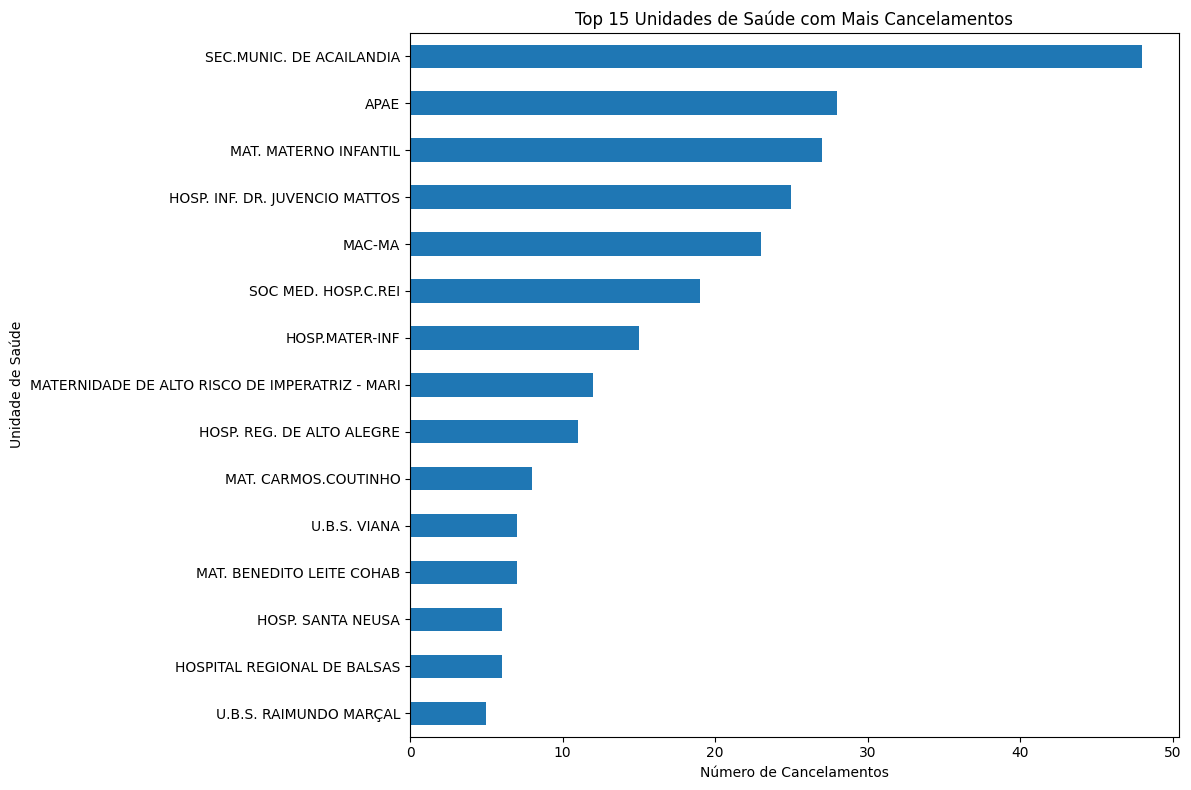

In [ ]:
# Visualizar as unidades com mais cancelamentos
plt.figure(figsize=(12, 8))
top_unidades.plot(kind='barh')
plt.title('Top 15 Unidades de Saúde com Mais Cancelamentos')
plt.xlabel('Número de Cancelamentos')
plt.ylabel('Unidade de Saúde')
plt.gca().invert_yaxis()  # Para mostrar a maior no topo
plt.tight_layout()
plt.show()

In [ ]:
# 2. Relacionar com municípios
df_canceladas_com_unidade.columns

Index(['co_seq_amostra', 'co_seq_tp_amostra', 'co_seq_pessoa',
       'co_seq_tp_material_coletado', 'co_seq_unidade_saude', 'nu_amostra',
       'ide_controle_medico', 'ide_portador', 'dt_col_amostra',
       'hr_col_amostra', 'dt_post_amostra', 'dt_rec_amostra',
       'dt_hr_cancelamento', 'aut_cancelamento', 'dt_hr_ultima_alteracao_x',
       'aut_ultima_alteracao_x', 'dt_hr_registro_x', 'aut_registro_x',
       'ide_transfusao_amostra', 'co_mot_inadequacao', 'ds_mot_inadequacao',
       'dt_hr_ultima_alteracao_y', 'aut_ultima_alteracao_y',
       'dt_hr_registro_y', 'aut_registro_y', 'ide_outro', 'co_mot_inad',
       'no_unidade_saude'],
      dtype='object')

In [ ]:
# 1. Relacionar amostras canceladas com unidades de saúde
df_canceladas_com_unidade = df_amostra[df_amostra['dt_hr_cancelamento'].notna()].merge(
    df_unidade_saude,
    on='co_seq_unidade_saude',
    how='left',
    suffixes=('', '_unidade')
)

In [ ]:
# Contagem de cancelamentos por município
# 2. Relacionar com municípios
df_canceladas_com_municipio = df_canceladas_com_unidade.merge(
    df_municipio[['co_seq_municipio', 'no_municipio']],
    on='co_seq_municipio',
    how='left',
    suffixes=('', '_municipio')
)



In [ ]:
# Contagem de cancelamentos por município
df_cancelamentos_por_municipio = df_canceladas_com_municipio['no_municipio'].value_counts()

top_20_municipios = df_cancelamentos_por_municipio.head(20)
print("Top 20 municípios com mais cancelamentos:")
for i, (municipio, quantidade) in enumerate(top_20_municipios.items(), 1):
    print(f"{i:2d}. {municipio}: {quantidade:,}")


Top 20 municípios com mais cancelamentos:
 1. São Luís: 127
 2. Açailândia: 50
 3. Imperatriz: 27
 4. Balsas: 25
 5. Caxias: 20
 6. Bacabal: 15
 7. Alto Alegre do Maranhão: 11
 8. Grajaú: 8
 9. Viana: 7
10. Araioses: 7
11. Mirador: 7
12. Coroatá: 7
13. Parnarama: 6
14. Porto Franco: 6
15. Timbiras: 5
16. Amarante do Maranhão: 5
17. Chapadinha: 5
18. Codó: 5
19. Cândido Mendes: 5
20. Bom Jardim: 5


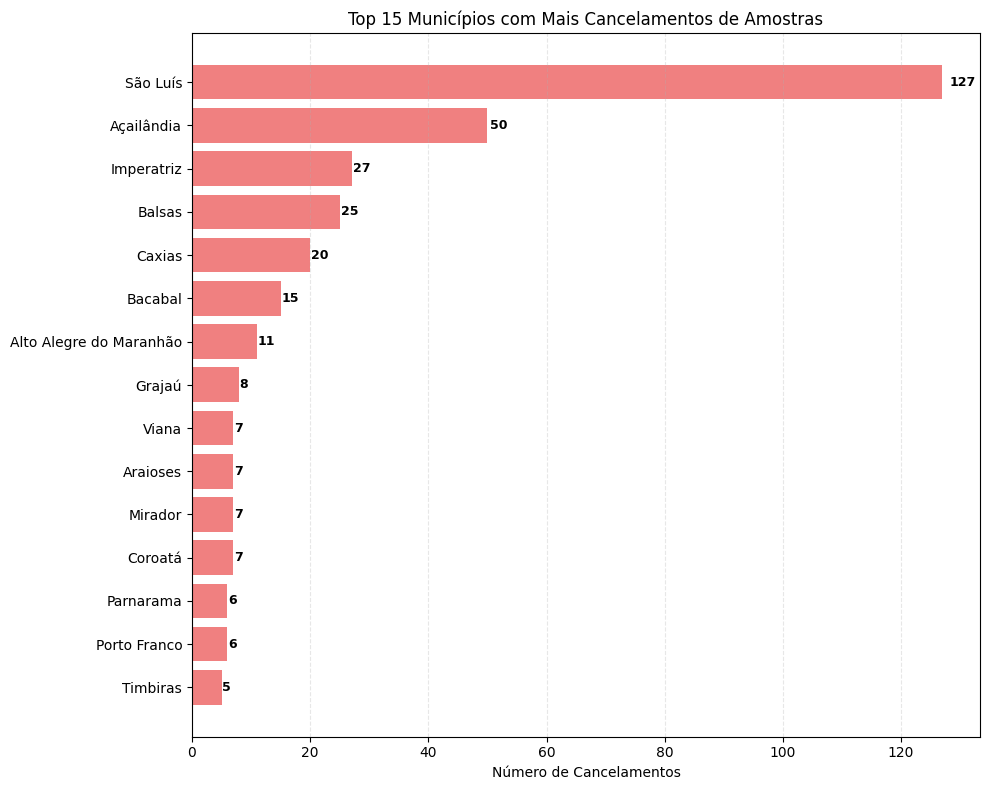

In [ ]:
# Gráfico de barras horizontais
df_top_15_municipios = top_20_municipios.head(15)

plt.figure(figsize=(10, 8)) 
bars = plt.barh(df_top_15_municipios.index, df_top_15_municipios.values, color='lightcoral')

plt.xlabel('Número de Cancelamentos')
plt.title('Top 15 Municípios com Mais Cancelamentos de Amostras')

plt.gca().invert_yaxis()

for bar in bars:
    valor = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    
    plt.text(valor * 1.01, y_pos, 
             f'{valor:,.0f}', 
             ha='left', va='center', fontweight='bold', fontsize=9)
    
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
print("DISTRIBUIÇÃO PERCENTUAL DOS CANCELAMENTOS")

# Calcular percentuais
df_total_cancelamentos_com_municipio = df_cancelamentos_por_municipio.sum()
top_10_municipios = df_cancelamentos_por_municipio.head(10)
percentuais = (top_10_municipios / df_total_cancelamentos_com_municipio * 100).round(2)


DISTRIBUIÇÃO PERCENTUAL DOS CANCELAMENTOS


In [ ]:
print("Percentual dos top 10 municípios no total de cancelamentos:")
for i, (municipio, percentual) in enumerate(percentuais.items(), 1):
    print(f"{i:2d}. {municipio}: {percentual:.2f}%")

Percentual dos top 10 municípios no total de cancelamentos:
 1. São Luís: 21.31%
 2. Açailândia: 8.39%
 3. Imperatriz: 4.53%
 4. Balsas: 4.19%
 5. Caxias: 3.36%
 6. Bacabal: 2.52%
 7. Alto Alegre do Maranhão: 1.85%
 8. Grajaú: 1.34%
 9. Viana: 1.17%
10. Araioses: 1.17%


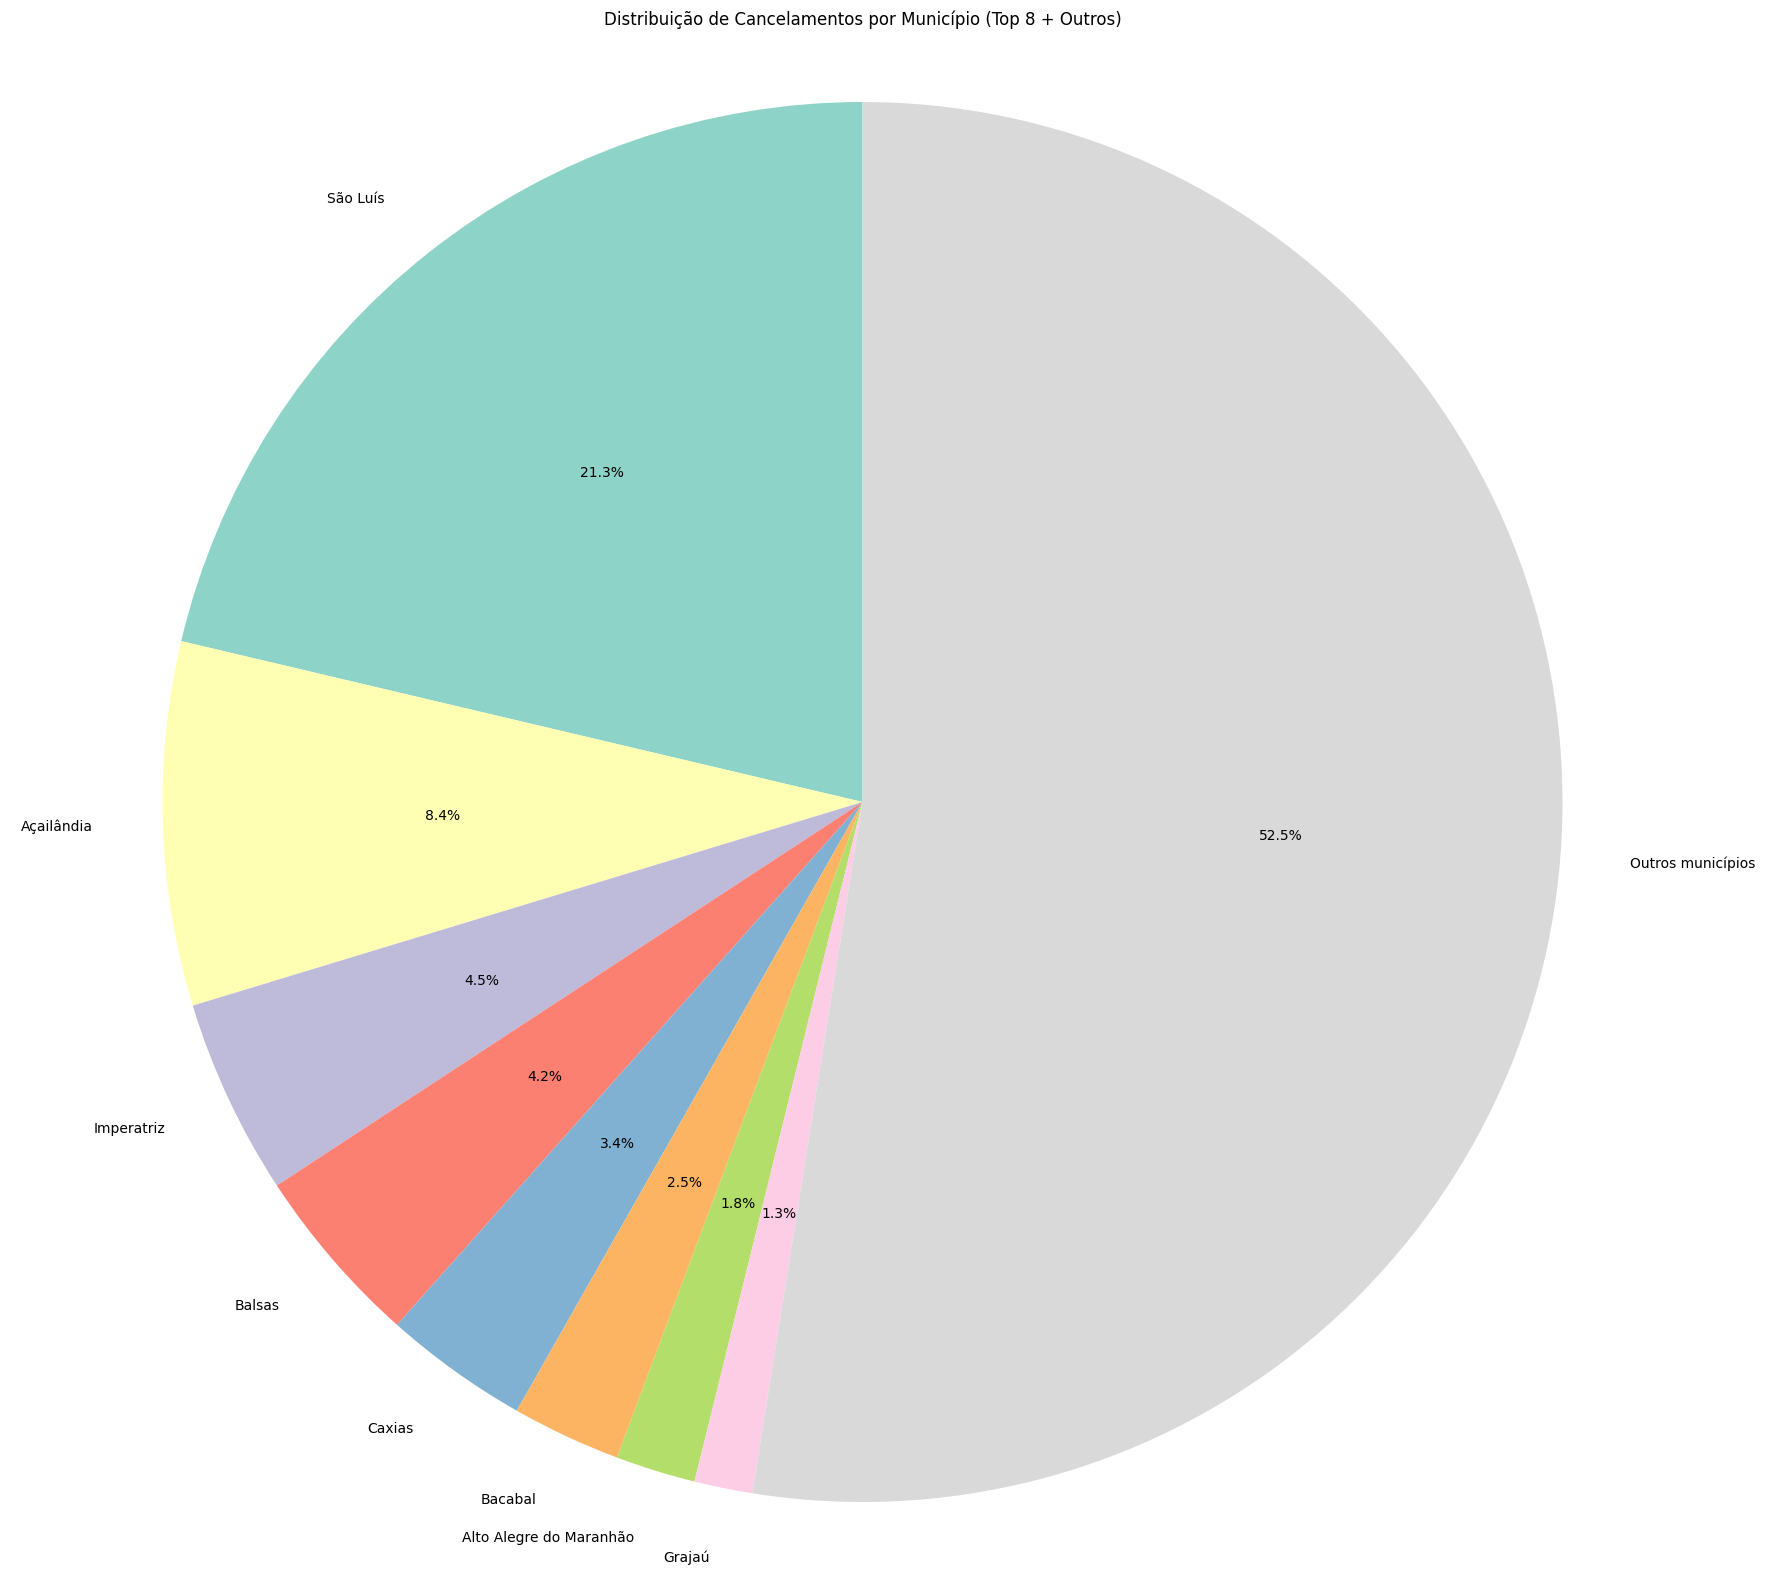

In [ ]:
# Gráfico de pizza para os top 8 municípios
plt.figure(figsize=(22, 20))
top_8_municipios = df_cancelamentos_por_municipio.head(8)
outros = df_cancelamentos_por_municipio.iloc[8:].sum()

# Preparar dados para o gráfico
labels = list(top_8_municipios.index) + ['Outros municípios']
sizes = list(top_8_municipios.values) + [outros]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=plt.cm.Set3.colors)
plt.title('Distribuição de Cancelamentos por Município (Top 8 + Outros)')
plt.axis('equal')
plt.show()

In [ ]:
df_silenciosos = df_amostras_canceladas[df_amostras_canceladas['ds_mot_inadequacao'].isna()].copy()

In [ ]:
df_analise = pd.merge(
    df_silenciosos[['co_seq_unidade_saude', 'aut_cancelamento', 'co_seq_amostra']],
    df_unidade_saude[['co_seq_unidade_saude', 'no_unidade_saude']],
    on='co_seq_unidade_saude',
    how='left'
)

In [ ]:
df_analise

,co_seq_unidade_saude,aut_cancelamento,co_seq_amostra,no_unidade_saude
0,133,carliane,82590,HOSP. SANTA NEUSA
1,139,thaiane,81846,U.B.S. SÃO FRANCISCO
2,262,thaiane,81359,HOSP.CARLOS MACIEIRA
3,277,thaiane,78869,APAE
4,74,erlandia,85477,MAT. CARMOS.COUTINHO
...,...,...,...,...
575,262,cristiana,71751,HOSP.CARLOS MACIEIRA
576,218,carliane,77493,HOSP. MUN. JESUS DE NAZARÉ
577,299,thaiane,78765,HOSP. INF. DR. JUVENCIO MATTOS
578,136,thaiane,78800,HOSP. ELDA R. FONSECA


In [ ]:
ranking_silencioso = (
    df_analise.groupby(['no_unidade_saude', 'aut_cancelamento'])
    .size()
    .rename('Contagem_Cancelamentos_Silenciosos')
    .sort_values(ascending=False)
    .reset_index()
)

In [ ]:
ranking_silencioso

,no_unidade_saude,aut_cancelamento,Contagem_Cancelamentos_Silenciosos
0,SEC.MUNIC. DE ACAILANDIA,ADMIN,46
1,SOC MED. HOSP.C.REI,ADMIN,19
2,HOSP. INF. DR. JUVENCIO MATTOS,cristiana,19
3,MAT. MATERNO INFANTIL,cristiana,16
4,APAE,cristiana,15
...,...,...,...
317,HOSP.MUNC.VALDIR MELO,cristiana,1
318,HOSP.MUNC.DE ZE DOCA,carliane,1
319,HOSP.MUNC.DE ZE DOCA,ADMIN,1
320,HOSP.MUN.PEDRO DOS REIS FERNANDES NETO,cristiana,1


In [ ]:
df_profissao

,co_seq_profissao,no_profissao,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,co_cbo
0,34,AUXILIAR DE LABORATÓRIO,20130501000000,Implantação,20130501000000,Implantação,NaN
1,41,NUTRICIONISTA,20130501000000,Implantação,20130501000000,Implantação,NaN
2,53,AGENTE COMUNITÁRIO DE SAÚDE,20130501000000,Implantação,20130501000000,Implantação,NaN
3,83,TÉCNICO (A) DE LABORATÓRIO,20130501000000,Implantação,20130501000000,Implantação,NaN
4,94,BIÓLOGO (A),20150506115646,Admin,20130501000000,Implantação,221105.0
...,...,...,...,...,...,...,...
101,561,MEDICO (A) CLINICO GERAL,20160516132801,ADMIN,20160516132801,ADMIN,225125.0
102,562,MEDICO (A) ENDOCRINOLOGISTA,20160516132801,ADMIN,20160516132801,ADMIN,225155.0
103,563,MEDICO (A) PEDIATRA,20160516132801,ADMIN,20160516132801,ADMIN,225124.0
104,564,MEDICO (A) PNEUMOLOGISTA,20160516132801,ADMIN,20160516132801,ADMIN,225127.0


In [ ]:
# DataFrames envolvidos:
df_amostras = df_amostra.copy()
df_profissionais = df_profissional_saude.copy()
df_profissoes = df_profissao.copy()



In [ ]:
# Chaves:
CHAVE_REGISTRO = 'aut_registro' # Chave de autenticação que liga Amostra -> Profissional
CHAVE_ID_PROFISSAO = 'co_seq_profissao' # Chave que liga Profissional -> Profissão


In [ ]:
# Coerção para string para o campo de autenticação/login
df_profissionais[CHAVE_REGISTRO] = df_profissionais[CHAVE_REGISTRO].astype(str)
df_amostras[CHAVE_REGISTRO] = df_amostras[CHAVE_REGISTRO].astype(str)

# 2. MERGE de Profissão: Cria o lookup CHAVE_REGISTRO -> no_profissao
df_lookup_prof = pd.merge(
    df_profissionais[[CHAVE_REGISTRO, CHAVE_ID_PROFISSAO]],
    df_profissoes[[CHAVE_ID_PROFISSAO, 'no_profissao']],
    on=CHAVE_ID_PROFISSAO,
    how='left'
)

# 3. MERGE FINAL: Adiciona o nome da profissão a TODAS as amostras
df_amostras_final = pd.merge(
    df_amostras,
    df_lookup_prof,
    on=CHAVE_REGISTRO,
    how='left'
)


In [ ]:
# 4. CALCULAR DENOMINADOR (Total de Amostras Registradas por Profissão)
amostras_total_por_prof = (
    df_amostras_final.groupby('no_profissao')
    .size()
    .rename('Total_Amostras')
)
# 5. CALCULAR NUMERADOR (Total de Amostras CANCELADAS por Profissão)
# Filtra as amostras que não têm nulo em 'dt_hr_cancelamento' (indicando cancelamento)
df_canceladas_por_profissao = df_amostras_final[df_amostras_final['dt_hr_cancelamento'].notna()]

cancelamentos_por_prof = (
    df_canceladas_por_profissao.groupby('no_profissao')
    .size()
    .rename('Total_Cancelamentos')
)


In [ ]:
# 6. CALCULAR O ÍNDICE DE CANCELAMENTO (KPI)
df_rank_final = pd.merge(
    cancelamentos_por_prof,
    amostras_total_por_prof,
    left_index=True,
    right_index=True,
    how='right' # Mantém todas as profissões, mesmo as que não cancelaram
).fillna(0) 

df_rank_final['Taxa_Cancelamento'] = (
    (df_rank_final['Total_Cancelamentos'] / df_rank_final['Total_Amostras']) * 100
)

# Ordenar e exibir o ranking
ranking_kpi = (
    df_rank_final.sort_values(by='Taxa_Cancelamento', ascending=False)
    .reset_index()
)
print("--- Ranking Final: Taxa de Cancelamento por Profissão (Top 10) ---")
print(ranking_kpi.head(10).to_markdown(index=False, floatfmt=".2f"))

--- Ranking Final: Taxa de Cancelamento por Profissão (Top 10) ---
| no_profissao                  |   Total_Cancelamentos |   Total_Amostras |   Taxa_Cancelamento |
|:------------------------------|----------------------:|-----------------:|--------------------:|
| FARMACÊUTICO ANALISTA CLINICO |                    11 |               11 |              100.00 |


In [ ]:
# Testando normalidade para múltiplas variáveis
variaveis = ['coluna1', 'coluna2', 'coluna3']  # Substitua pelos nomes reais das colunas

for var in variaveis:
    print(f"\n--- Teste de Normalidade para {var} ---")
    dados = df_amostras_com_motivos[var].dropna()
    shapiro_stat, shapiro_p = stats.shapiro(dados)
    print(f"Shapiro-Wilk: estatística={shapiro_stat:.3f}, p-valor={shapiro_p:.3g}")
    if shapiro_p < 0.05:
        print("Distribuição NÃO é normal (p < 0.05). Recomenda-se análise não paramétrica.")
    else:
        print("Distribuição é aproximadamente normal (p >= 0.05). Pode-se considerar análise paramétrica.")